Author: Mariana Savchuk, 7249523

In [83]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [84]:
file_path = 'data/data.csv'

df = pd.read_csv(file_path,delimiter=';')
pd.set_option('display.max_columns', None)

In [85]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [86]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance\t                      0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

<Figure size 1000x1200 with 0 Axes>

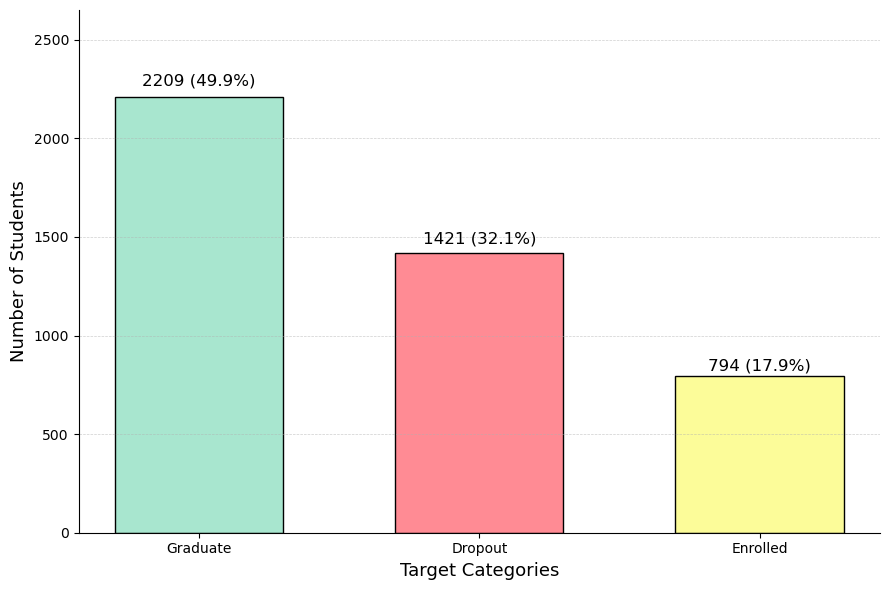

In [87]:
target_counts = df['Target'].value_counts()
labels = target_counts.index
sizes = target_counts.values
total = sizes.sum()

colors = ['#A8E6CF', '#FF8B94', '#FCFC99']

plt.rcParams.update(plt.rcParamsDefault)

plt.figure(figsize=(9, 6))
bars = plt.bar(labels, sizes, color=colors, edgecolor='black', width=0.6)


plt.xlabel('Target Categories', fontsize=13)
plt.ylabel('Number of Students', fontsize=13)


for bar, count in zip(bars, sizes):
    percent = (count / total) * 100
    label = f'{count} ({percent:.1f}%)'
    plt.text(bar.get_x() + bar.get_width() / 2, count + (count * 0.02),
             label, ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(sizes) * 1.2)


plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.6)


plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


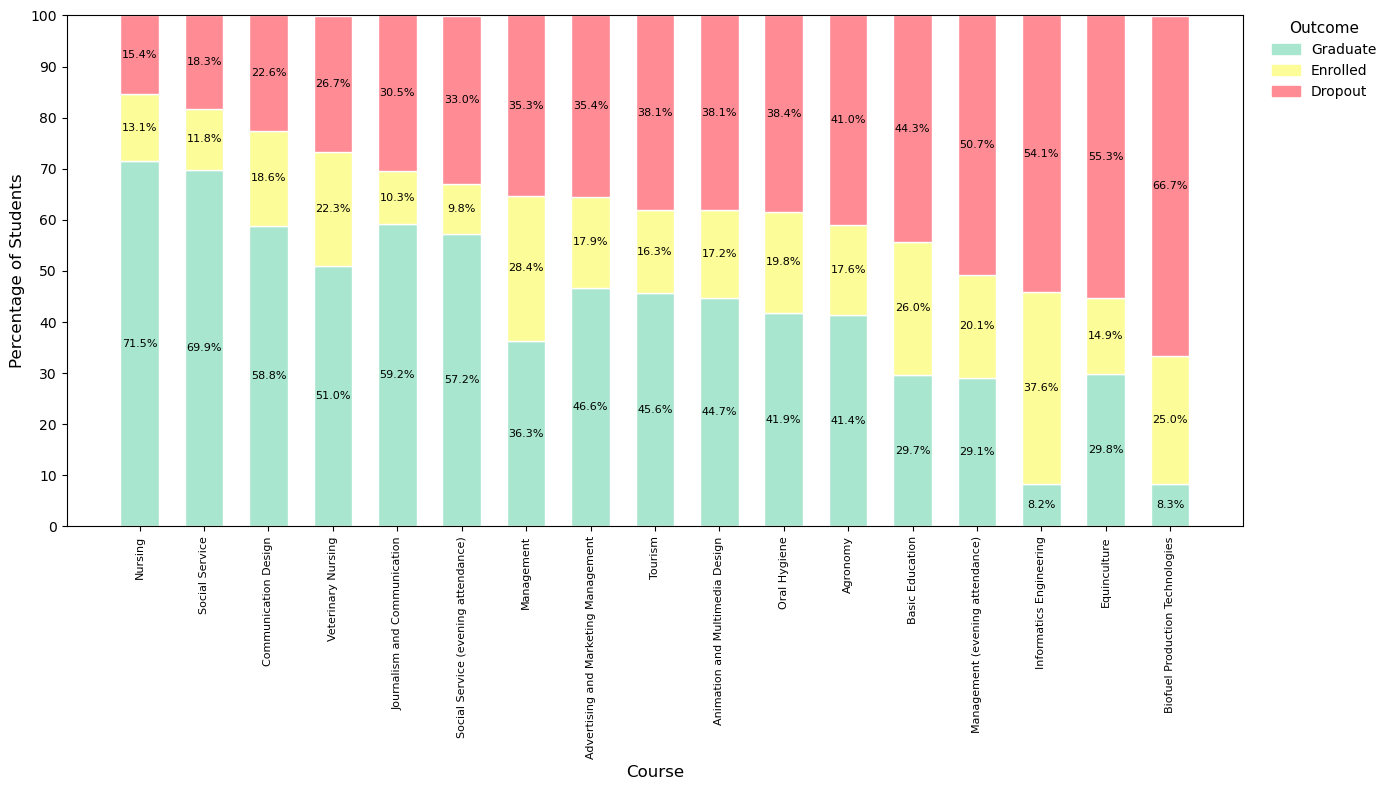

In [88]:
course_map = {
    33: 'Biofuel Production Technologies',
    171: 'Animation and Multimedia Design',
    8014: 'Social Service (evening attendance)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Engineering',
    9130: 'Equinculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advertising and Marketing Management',
    9773: 'Journalism and Communication',
    9853: 'Basic Education',
    9991: 'Management (evening attendance)'
}
df['Course Name'] = df['Course'].map(course_map)

df_courses = df[df['Course Name'].notna()]

counts = df_courses.groupby(['Course Name', 'Target']).size().unstack(fill_value=0)
percentages = counts.div(counts.sum(axis=1), axis=0) * 100
percentages = percentages[['Graduate', 'Enrolled', 'Dropout']]

sorted_percentages = percentages.sort_values('Dropout')

colors = {'Graduate': '#A8E6CF', 'Enrolled': '#FCFC99', 'Dropout': '#FF8B94'}

fig, ax = plt.subplots(figsize=(14, 8))
bottom = pd.Series(0, index=sorted_percentages.index)

for outcome in sorted_percentages.columns:
    ax.bar(
        sorted_percentages.index,
        sorted_percentages[outcome],
        bottom=bottom,
        color=colors[outcome],
        edgecolor='white',
        width=0.6
    )
    for i, pct in enumerate(sorted_percentages[outcome]):
        if pct >= 5:
            y = bottom.iloc[i] + pct / 2
            ax.text(i, y, f"{pct:.1f}%", ha='center', va='center', fontsize=8, color='black')
    bottom += sorted_percentages[outcome]

#ax.set_title("Outcome Distribution (%) by Course", fontsize=14)
ax.set_ylabel("Percentage of Students", fontsize=12)
ax.set_xlabel("Course", fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks(range(0, 101, 10))
ax.set_xticks(range(len(sorted_percentages)))
ax.set_xticklabels(sorted_percentages.index, rotation=90, fontsize=8)

handles = [plt.Rectangle((0,0),1,1, color=colors[o]) for o in ['Graduate','Enrolled','Dropout']]
labels = ['Graduate', 'Enrolled', 'Dropout']
ax.legend(handles, labels, title="Outcome", loc='upper left', 
          bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=False, title_fontsize=11, fontsize=10)

plt.tight_layout()
plt.show()


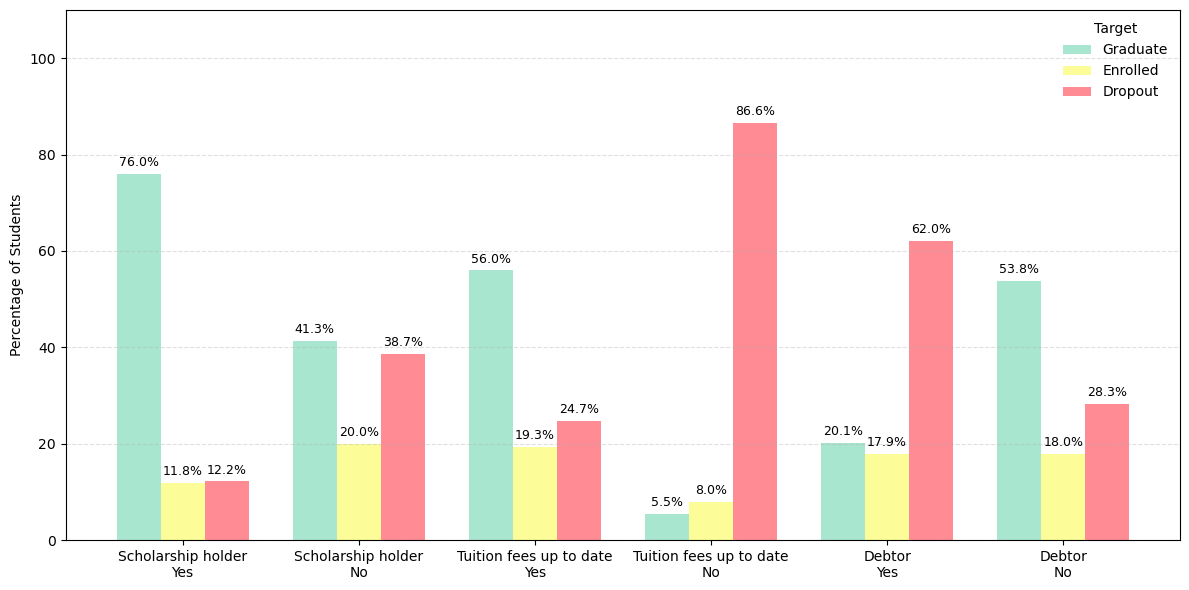

In [89]:
df['Debtor'] = df['Debtor'].map({0: 'No', 1: 'Yes'})
df['Tuition fees up to date'] = df['Tuition fees up to date'].map({0: 'No', 1: 'Yes'})
df['Scholarship holder'] = df['Scholarship holder'].map({0: 'No', 1: 'Yes'})

features = ['Scholarship holder', 'Tuition fees up to date', 'Debtor']
target_order = ['Graduate', 'Enrolled', 'Dropout']
colors = {'Graduate': '#A8E6CF', 'Enrolled': '#FCFC99', 'Dropout': '#FF8B94'}

labels = []
values = []

for feature in features:
    counts = df.groupby([feature, 'Target']).size().unstack(fill_value=0)[target_order]
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    
    for level in ['Yes', 'No']:
        labels.append(f"{feature}\n{level}")
        if level in pct.index:
            values.append(pct.loc[level].values)
        else:
            values.append(np.zeros(len(target_order)))

values = np.array(values)

n_groups = values.shape[0]
x = np.arange(n_groups)
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, target in enumerate(target_order):
    ax.bar(x + (i-1)*width, values[:, i], width, color=colors[target], label=target)
    for j, v in enumerate(values[:, i]):
        if v >= 3:
            ax.text(x[j] + (i-1)*width, v + 1, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=10)
ax.set_ylabel('Percentage of Students')
#ax.set_title('Target Distribution by Financial Variables', fontweight='bold')
ax.set_ylim(0, 110)
ax.grid(axis='y', linestyle='--', alpha=0.4)

ax.legend(title='Target', loc='upper right', frameon=False)

plt.tight_layout()
plt.show()


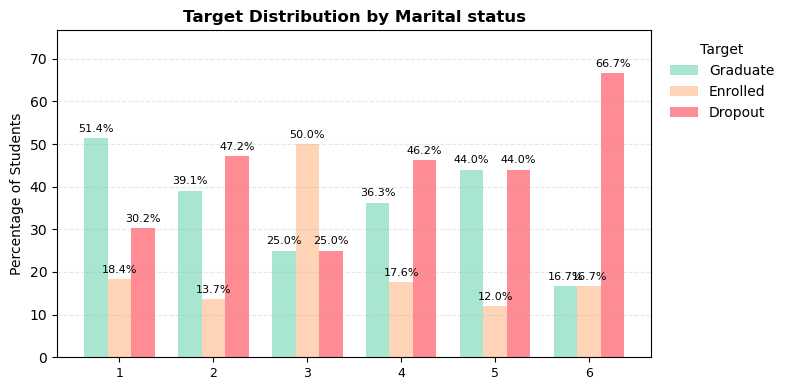

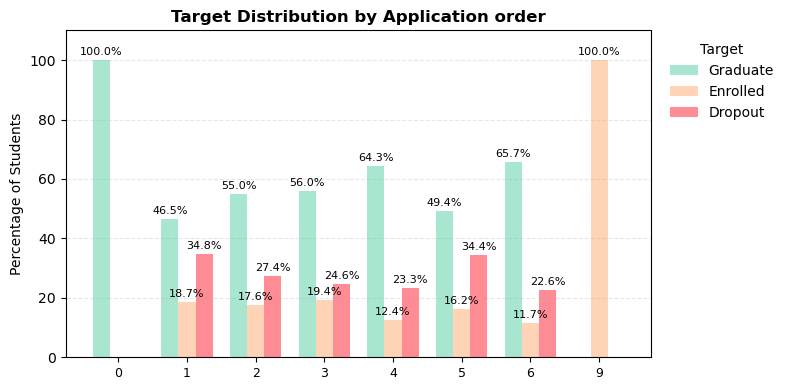

/tmp/ipykernel_58265/3467202682.py:43: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/david/miniforge3/envs/ds/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


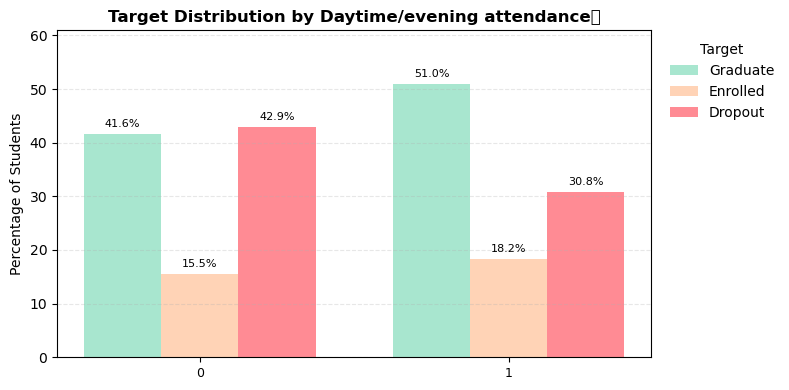

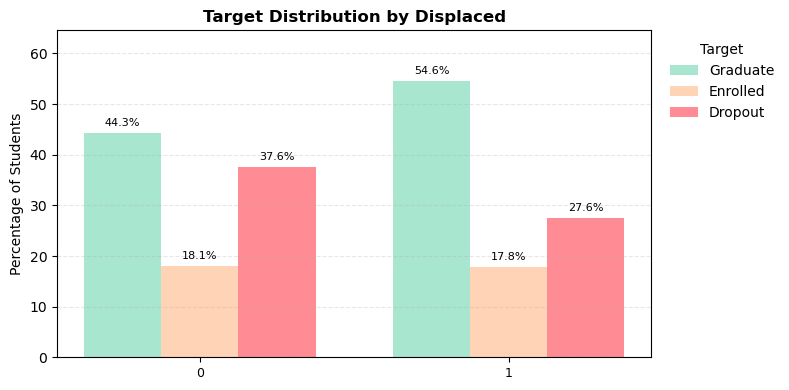

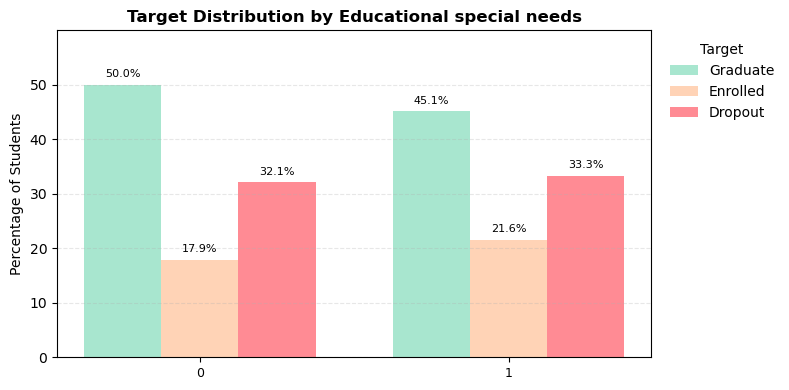

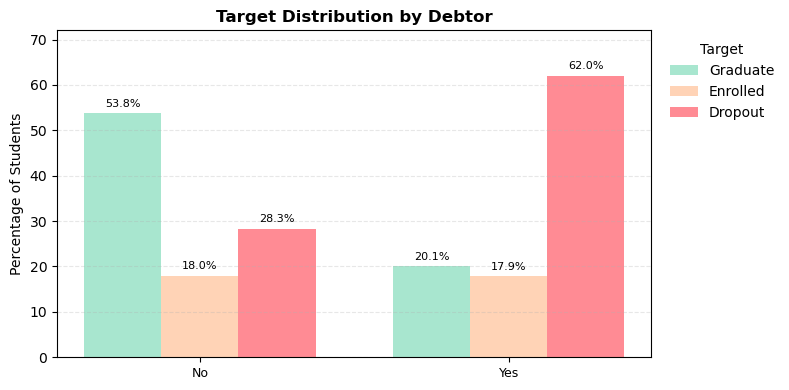

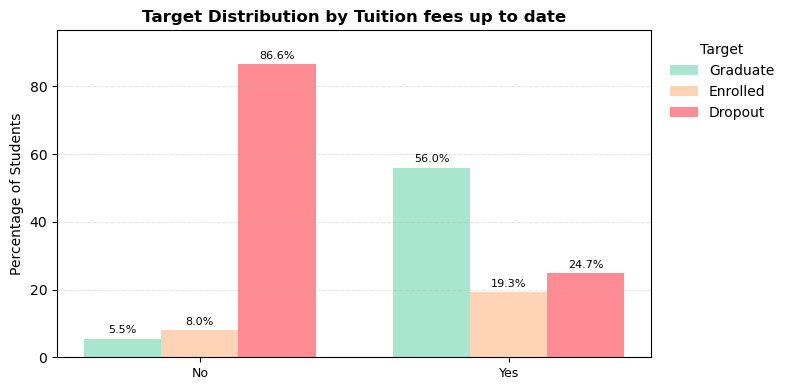

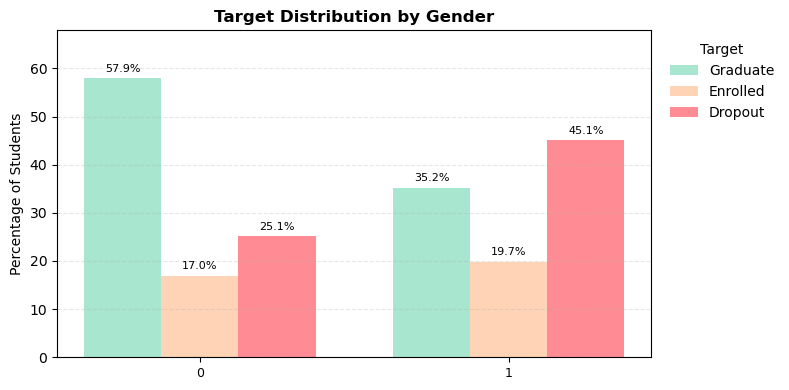

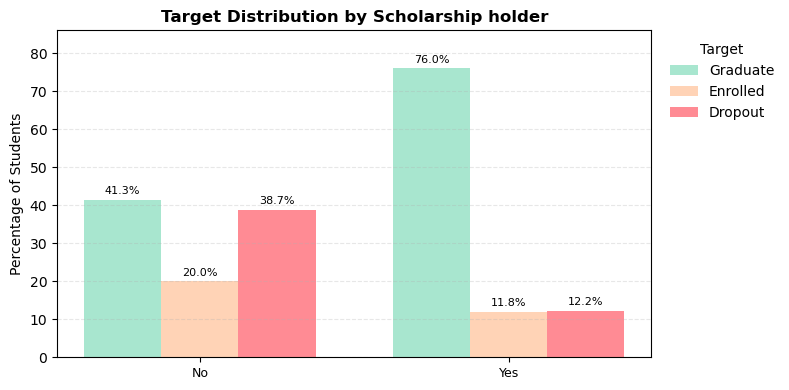

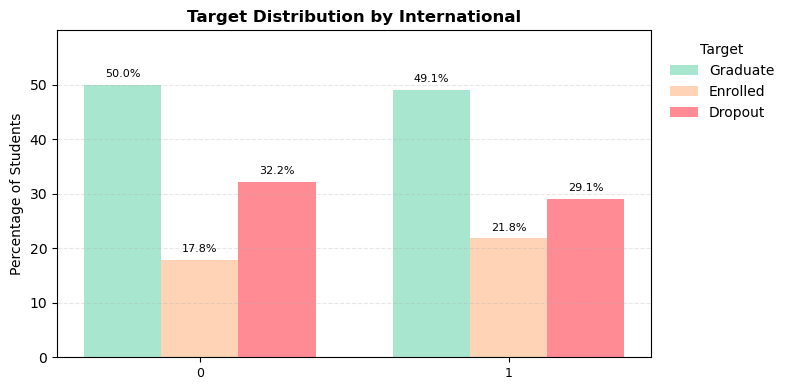

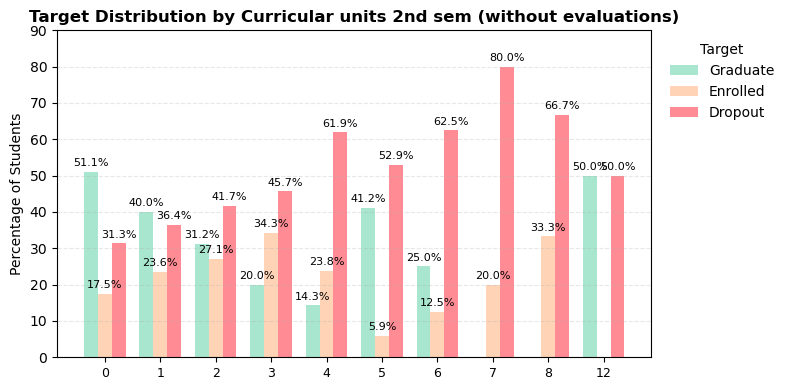

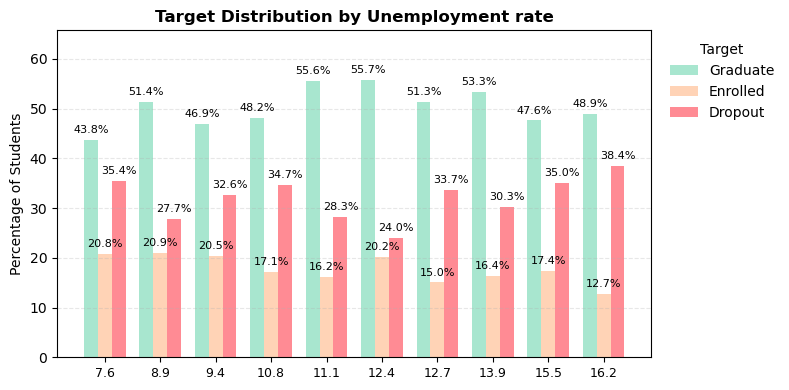

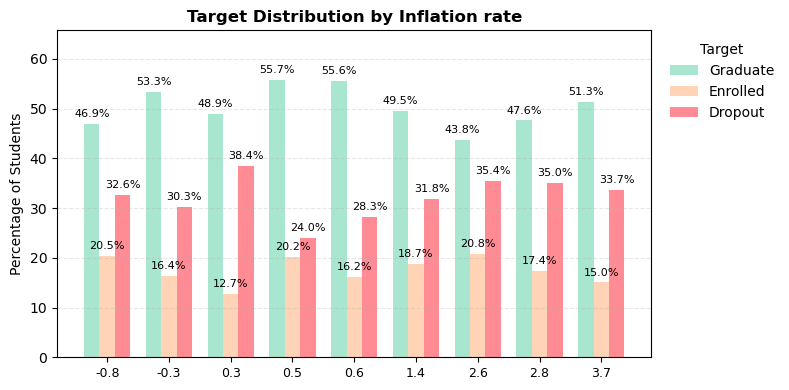

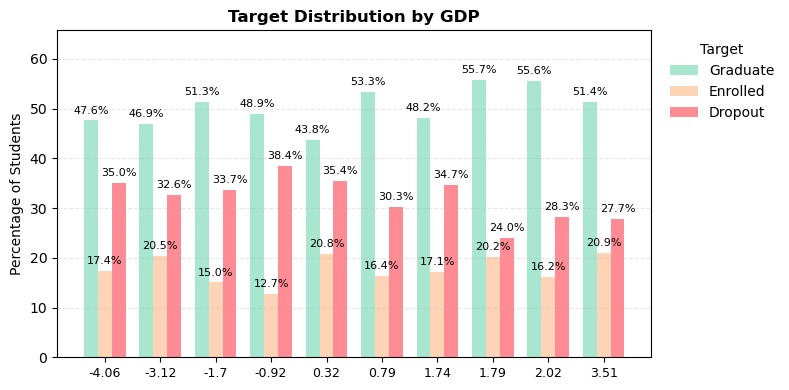

In [90]:
binary_map = {0: 'No', 1: 'Yes'}
for col in ['Debtor', 'Tuition fees up to date', 'Scholarship holder']:
    if col in df.columns and df[col].dtype in [np.int64, np.float64]:
        df[col] = df[col].map(binary_map)

features = [col for col in df.columns if col != 'Target']
target_order = ['Graduate', 'Enrolled', 'Dropout']
colors = {'Graduate':'#A8E6CF', 'Enrolled':'#FFD3B6', 'Dropout':'#FF8B94'}
bar_width = 0.25


for feature in features:
    levels = df[feature].dropna().unique().tolist()
    if len(levels) > 10:
        continue
    
    counts = df.groupby([feature, 'Target']).size().unstack(fill_value=0)
    counts = counts.reindex(columns=target_order, fill_value=0)
    pct = counts.div(counts.sum(axis=1), axis=0) * 100
    
    x = np.arange(len(pct))
    
    fig, ax = plt.subplots(figsize=(8,4))
    for i, t in enumerate(target_order):
        ax.bar(x + (i-1)*bar_width, pct[t], bar_width,
               color=colors[t], label=t)
        for j, val in enumerate(pct[t]):
            if val >= 3:
                ax.text(x[j] + (i-1)*bar_width, val+1, f"{val:.1f}%", 
                        ha='center', va='bottom', fontsize=8)
    
    ax.set_xticks(x)
    ax.set_xticklabels(pct.index, rotation=0, ha='center', fontsize=9)
    ax.set_ylabel('Percentage of Students')
    ax.set_title(f'Target Distribution by {feature}', fontweight='bold')
    ax.set_ylim(0, pct.values.max() + 10)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.legend(title='Target', loc='upper left', bbox_to_anchor=(1.01, 1), frameon=False)



    
    plt.tight_layout()
    plt.show()


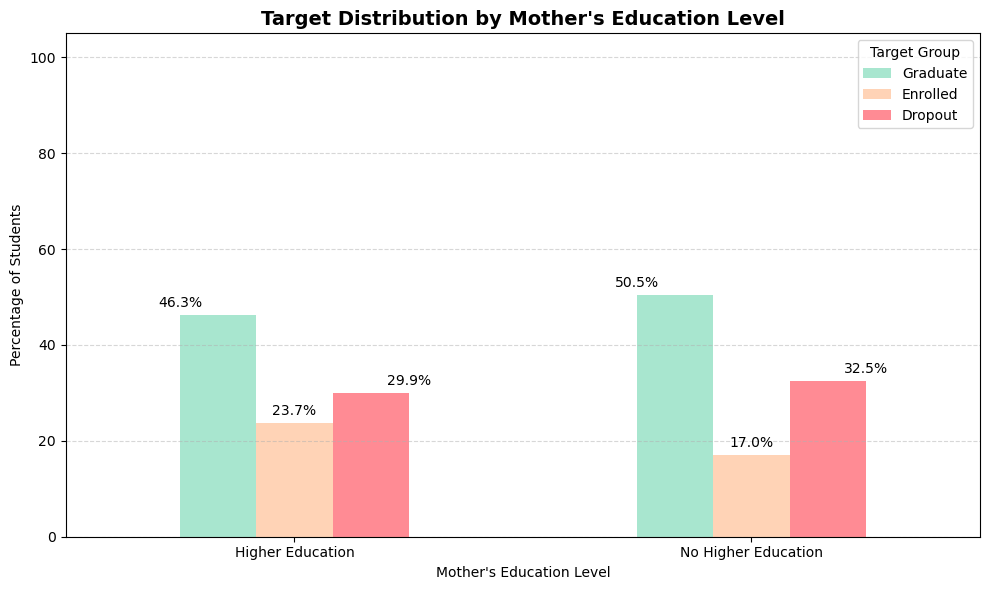

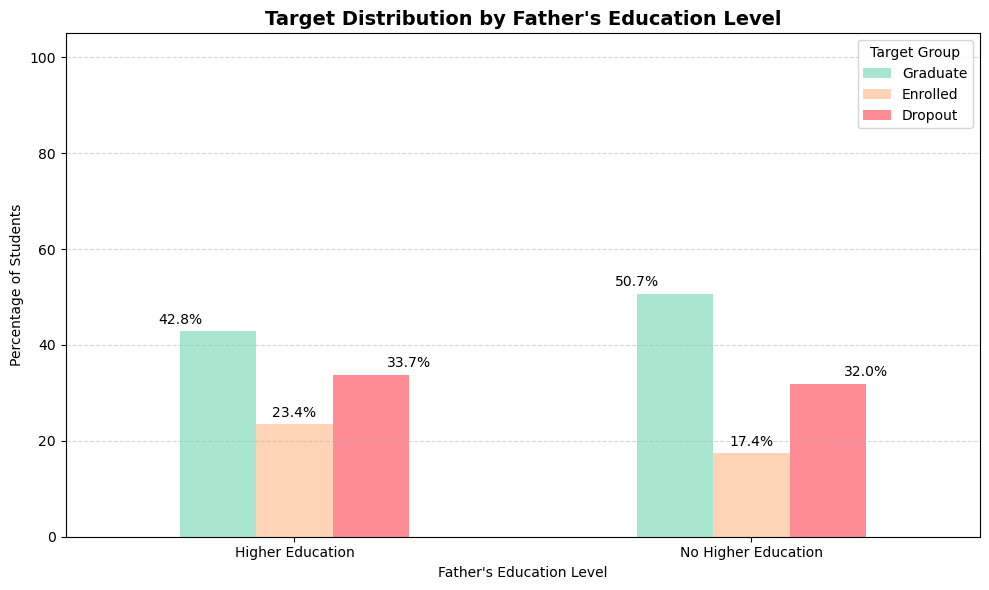

In [91]:
def map_mother_qualification(x):
    if x in [2, 3, 4, 5, 40, 41, 42, 43, 44]:
        return "Higher Education"
    else:
        return "No Higher Education"

def map_father_qualification(x):
    if x in [2, 3, 4, 5, 40, 41, 42, 43, 44]:
        return "Higher Education"
    else:
        return "No Higher Education"

df['MotherQualGroup'] = df["Mother's qualification"].apply(map_mother_qualification)
df['FatherQualGroup'] = df["Father's qualification"].apply(map_father_qualification)

qualification_order = ['Higher Education', 'No Higher Education']
target_order = ['Graduate', 'Enrolled', 'Dropout']
colors = {'Graduate':'#A8E6CF', 'Enrolled':'#FFD3B6', 'Dropout':'#FF8B94'}

def plot_percent_bars(group_col, title):
    counts = df.groupby([group_col, 'Target']).size().unstack(fill_value=0).loc[qualification_order]
    counts = counts[target_order] 
    percentages = counts.div(counts.sum(axis=1), axis=0) * 100

    ax = percentages.plot(kind='bar', figsize=(10, 6), color=colors)

    for i, row in enumerate(percentages.values):
        for j, value in enumerate(row):
            if value > 3:
                ax.text(i + (j - 1) * 0.25, value + 1, f'{value:.1f}%', 
                        ha='center', va='bottom', fontsize=10)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(f"{group_col.replace('QualGroup', '')}'s Education Level")
    plt.ylabel("Percentage of Students")
    plt.ylim(0, 105)
    plt.xticks(rotation=0)
    plt.legend(title='Target Group')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

plot_percent_bars('MotherQualGroup', "Target Distribution by Mother's Education Level")
plot_percent_bars('FatherQualGroup', "Target Distribution by Father's Education Level")

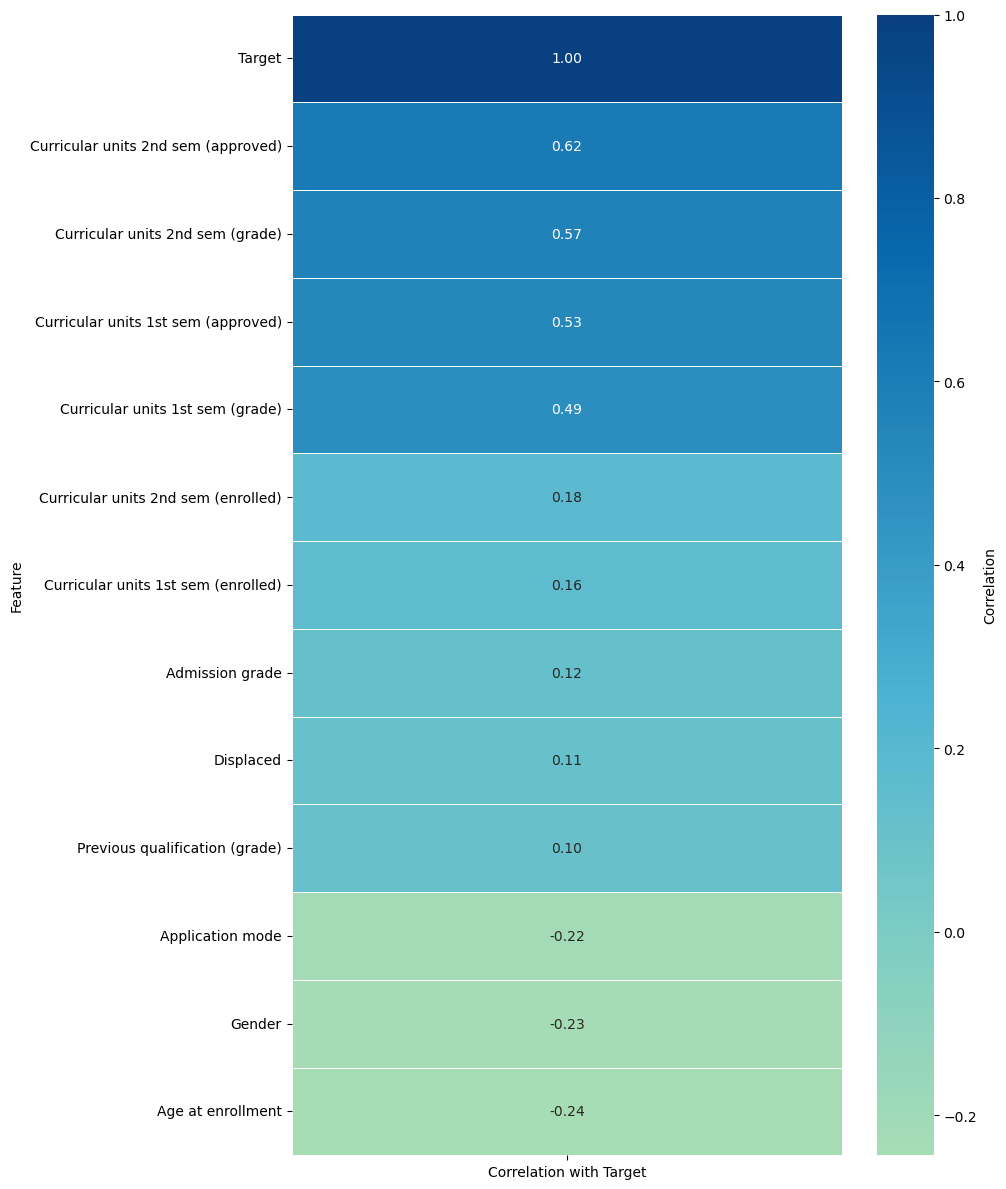

In [ ]:
df['Target'] = df['Target'].map({'Dropout': 0, 'Enrolled':1, 'Graduate': 2})

numeric_df = df.select_dtypes(include='number')

correlations = numeric_df.corr()['Target'].sort_values(ascending=False).to_frame().reset_index()
correlations.columns = ['Feature', 'Correlation with Target']

correlations = correlations[
    (correlations["Correlation with Target"] >= 0.1) |
    (correlations["Correlation with Target"] <= -0.1)
]

plt.figure(figsize=(10, 12))
sns.heatmap(correlations.set_index('Feature'), annot=True, cmap='GnBu', center=0, linewidths=0.5, fmt=".2f", cbar_kws={'label': 'Correlation'})
plt.tight_layout()
plt.show()